In [1]:
with open('shelley-corpus/frankenstein.txt') as f:
    frankenstein = f.read()

In [2]:
import spacy

In [3]:
nlp = spacy.load('en_core_web_lg')

In [10]:
import re

def clean_gutenberg_text(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    start_pattern = r"\*\*\*\s*START OF.*?\*\*\*"
    end_pattern = r"\*\*\*\s*END OF.*?\*\*\*"

    start_match = re.search(start_pattern, text, re.DOTALL | re.IGNORECASE)
    end_match = re.search(end_pattern, text, re.DOTALL | re.IGNORECASE)

    if not start_match or not end_match:
        raise ValueError("Could not locate Gutenberg boundaries.")

    cleaned = text[start_match.end():end_match.start()]

    return cleaned.strip()

In [12]:
frankenstein = clean_gutenberg_text('shelley-corpus/frankenstein.txt')
frank_doc = nlp(frankenstein)

In [8]:
from collections import Counter
freqs = Counter(
            token.lemma_.lower()
            for token in frank_doc
            if (
                not token.is_stop
                and not token.is_punct
                and not token.is_space
            )
        )

In [9]:
freqs

Counter({'man': 181,
         'father': 134,
         'feel': 133,
         'day': 133,
         'work': 127,
         'life': 125,
         'friend': 125,
         'eye': 122,
         'see': 122,
         'find': 121,
         'time': 109,
         'shall': 107,
         'say': 107,
         'know': 105,
         'place': 104,
         'great': 102,
         'feeling': 99,
         'night': 98,
         'return': 96,
         'pass': 93,
         'elizabeth': 92,
         'project': 91,
         'mind': 90,
         'appear': 90,
         'love': 89,
         'gutenberg': 88,
         'hear': 88,
         'think': 87,
         'dear': 85,
         'heart': 85,
         'long': 83,
         'come': 83,
         'death': 82,
         'take': 80,
         'soon': 75,
         'remain': 74,
         'hope': 74,
         'creature': 69,
         'look': 68,
         'word': 67,
         'fear': 66,
         'enter': 66,
         'spirit': 65,
         'hand': 65,
         'miserable': 65,

In [17]:
fear_words = set()

with open("fear_lexicon.txt", "r", encoding="utf-8") as f:
    for line in f:
        word, label = line.strip().split("\t")

        if label == "1":
            fear_words.add(word.lower())

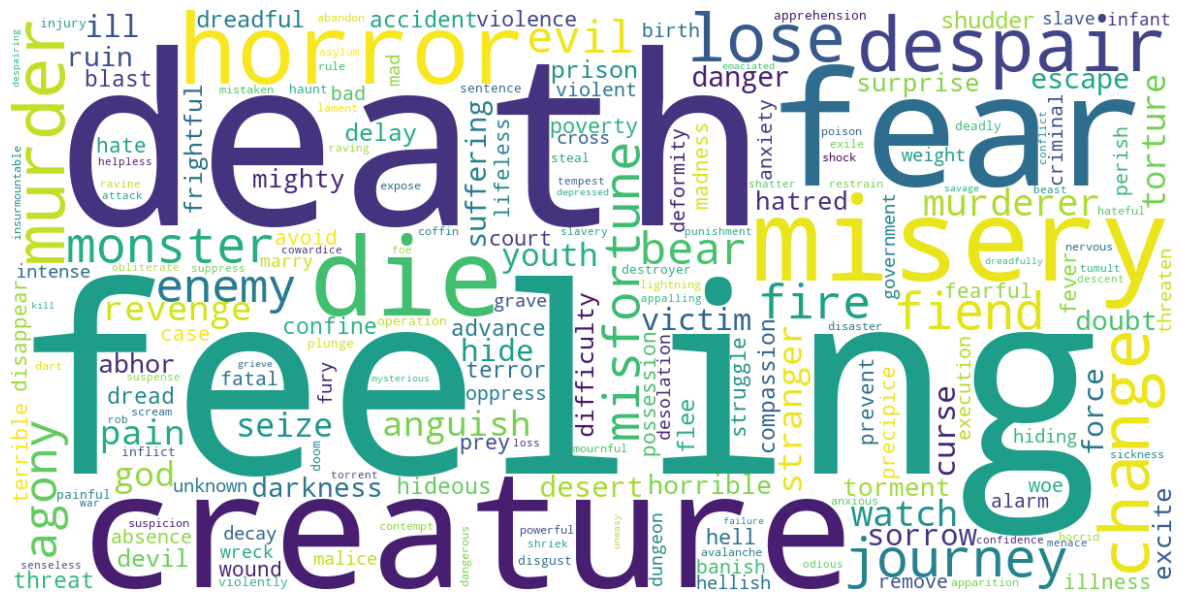

In [21]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load fear lexicon
fear_words = set()

with open("fear_lexicon.txt", "r", encoding="utf-8") as f:
    for line in f:
        word, label = line.strip().split("\t")

        if label == "1":
            fear_words.add(word.lower())

# Count lemmas in Frankenstein
lemma_counts = Counter()

for token in frank_doc:
    if (
        not token.is_punct
        and not token.is_space
        and not token.is_stop
    ):
        lemma = token.lemma_.lower()
        lemma_counts[lemma] += 1

# Keep only fear-related lemmas
fear_counts = {
    lemma: count
    for lemma, count in lemma_counts.items()
    if lemma in fear_words
}

# Generate word cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)

wc.generate_from_frequencies(fear_counts)

plt.figure(figsize=(15, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.savefig(
        f"frankenstein_fear_words.png",
        dpi=300,
        bbox_inches="tight"
    )
plt.show()

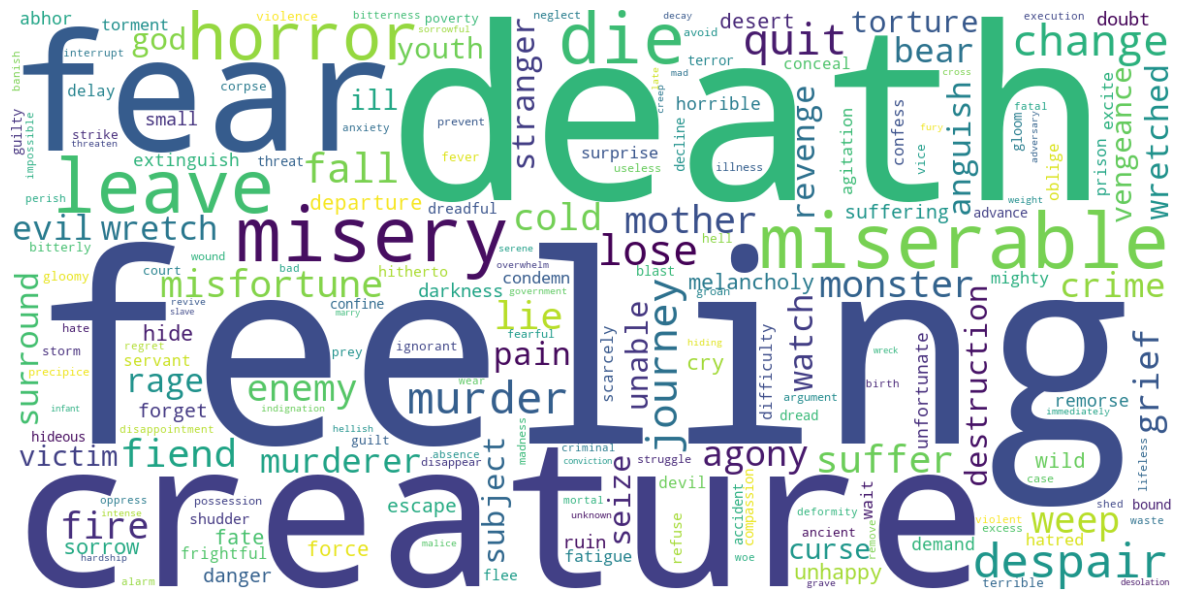

In [22]:
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

negative_words = set()

with open("negative_lexicon.txt", "r", encoding="utf-8") as f:
    for line in f:
        word, label = line.strip().split("\t")

        if label == "1":
            fear_words.add(word.lower())

# Count lemmas in Frankenstein
lemma_counts = Counter()

for token in frank_doc:
    if (
        not token.is_punct
        and not token.is_space
        and not token.is_stop
    ):
        lemma = token.lemma_.lower()
        lemma_counts[lemma] += 1

# Keep only fear-related lemmas
fear_counts = {
    lemma: count
    for lemma, count in lemma_counts.items()
    if lemma in fear_words
}

# Generate word cloud
wc = WordCloud(
    width=1200,
    height=600,
    background_color="white"
)

wc.generate_from_frequencies(fear_counts)

plt.figure(figsize=(15, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.savefig(
        f"frankenstein_negative_words.png",
        dpi=300,
        bbox_inches="tight"
    )
plt.show()